# 13 · Per-residue binding density on the real protein (all targets)

Where do the ligands actually sit on each target? For every folded complex we take that complex's own coordinates and, for each **chain-A residue**, its minimum distance to the ligand; a residue is in contact when the ligand comes within 5 A. Aggregating the **contact frequency per residue index** across all poses needs no alignment (every distance is measured inside one complex), so the profile sits on the **actual residues of the actual fold** - not a Kabsch-aligned reference frame.

For each target this notebook shows: (1) the **weight distribution per residue** along the full sequence (which residues the library binds, and how focused), and (2) that density **painted on the real CA backbone** in 3D. It self-fills as each target's structures finish folding.

In [1]:

from pathlib import Path
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from IPython.display import display
BLK="#000000"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff")
SHORT={"588689":"588689 (NS5 MTase)","504329":"504329","1053173-743445":"743445","493248-485317":"485317",
       "434954-2097":"2097","540297-493091":"493091","463203-2650":"2650","624273-588549":"588549"}
ALL=list(SHORT)
def load(t):
    p=ROOT/"results/runs"/t/"pose_density"/"residue_density.csv"; z=ROOT/"results/runs"/t/"pose_density"/"ca_colored.npz"
    if not p.exists() or not z.exists(): return None
    return pd.read_csv(p), np.load(z, allow_pickle=True)
DATA={t:load(t) for t in ALL}; DONE=[t for t in ALL if DATA[t] is not None]
print("targets with per-residue density:", [SHORT[t] for t in DONE])
print("pending:", [SHORT[t] for t in ALL if t not in DONE])


targets with per-residue density: ['588689 (NS5 MTase)', '504329', '743445', '485317', '2097', '493091', '2650', '588549']
pending: []


## Per-residue density profile + structure, per target
Left: contact frequency vs residue number (the binding-site fingerprint along the whole protein; a sharp peak = one focused pocket, multiple peaks = multiple sites). Right: the real CA backbone coloured by the same density (hot = high ligand occupancy). Top contacted residues are listed.

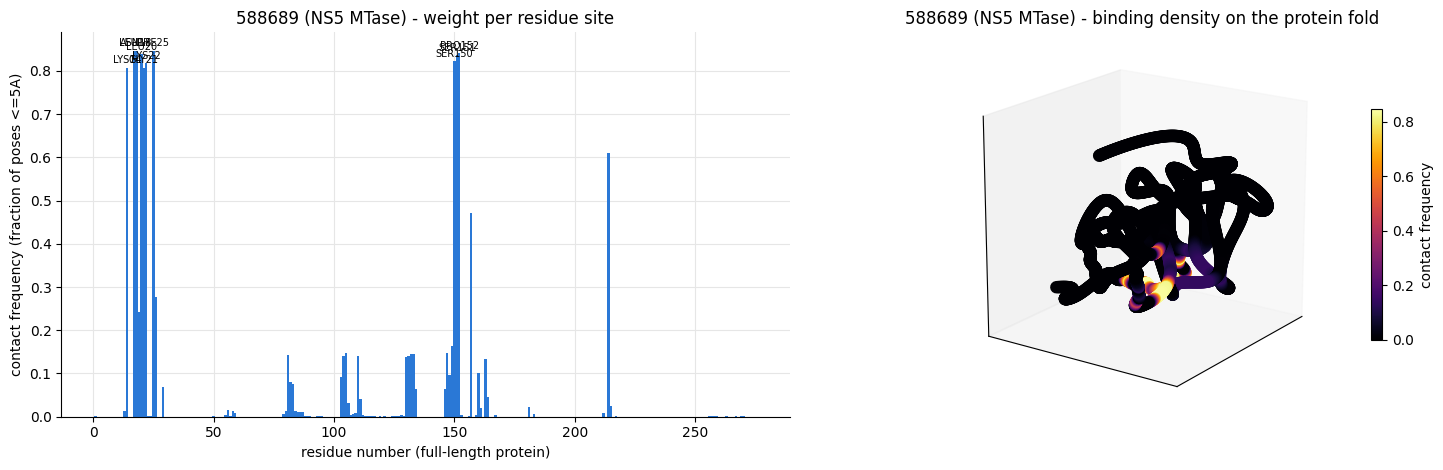

588689 (NS5 MTase): top binding residues: LEU17(0.85), ASN18(0.85), PHE25(0.85), PRO152(0.84), LEU20(0.84), SER151(0.84), SER150(0.82), LYS22(0.82)


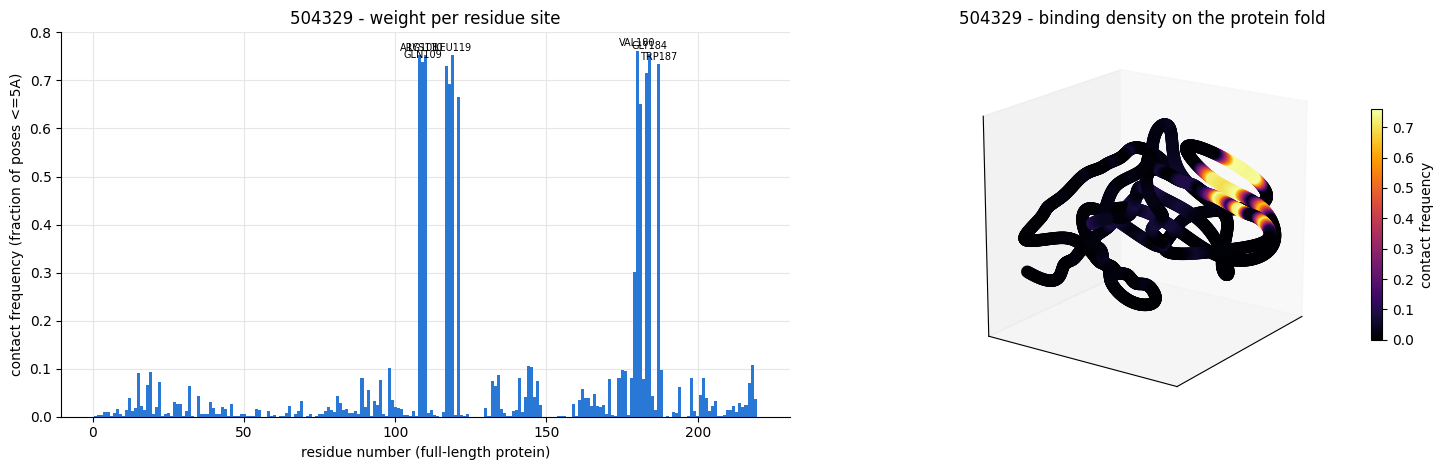

504329: top binding residues: VAL180(0.76), GLY184(0.76), LEU119(0.75), LYS110(0.75), ARG108(0.75), GLN109(0.74), TRP187(0.73), VAL117(0.73)


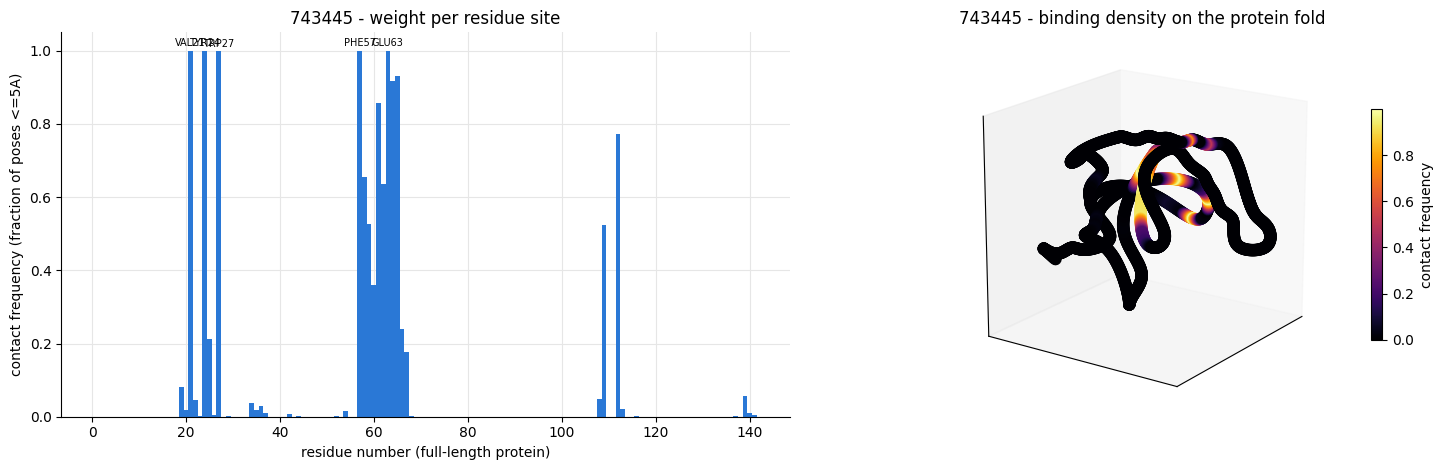

743445: top binding residues: VAL21(1.00), PHE57(1.00), GLU63(1.00), TYR24(1.00), TRP27(1.00), ALA65(0.93), ARG64(0.92), ALA61(0.86)


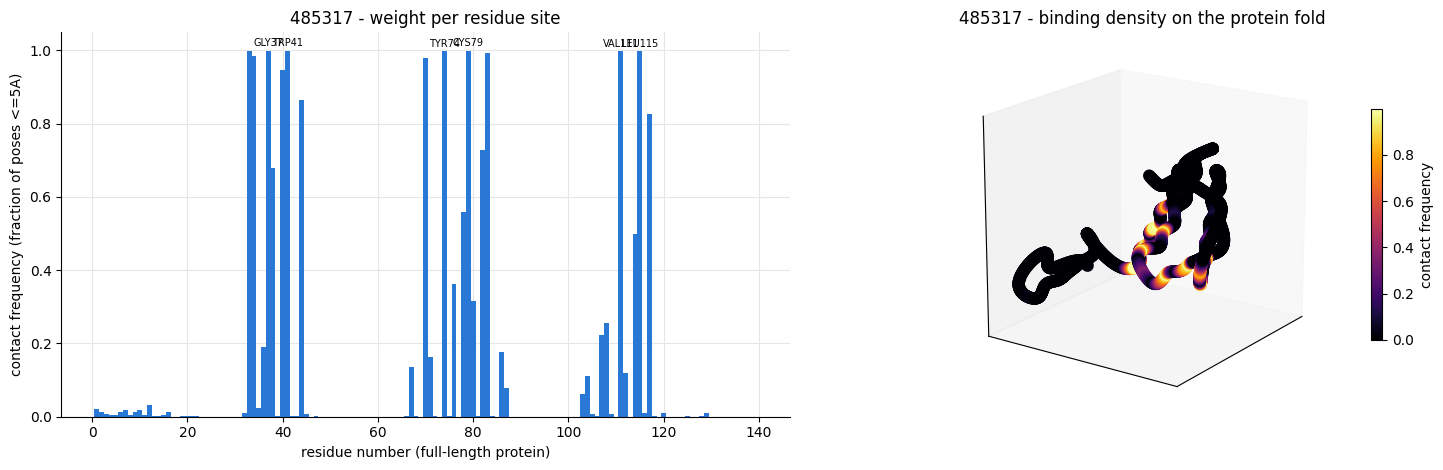

485317: top binding residues: CYS79(1.00), TRP41(1.00), GLY37(1.00), TYR74(1.00), VAL111(1.00), LEU115(1.00), ARG33(1.00), LEU83(0.99)


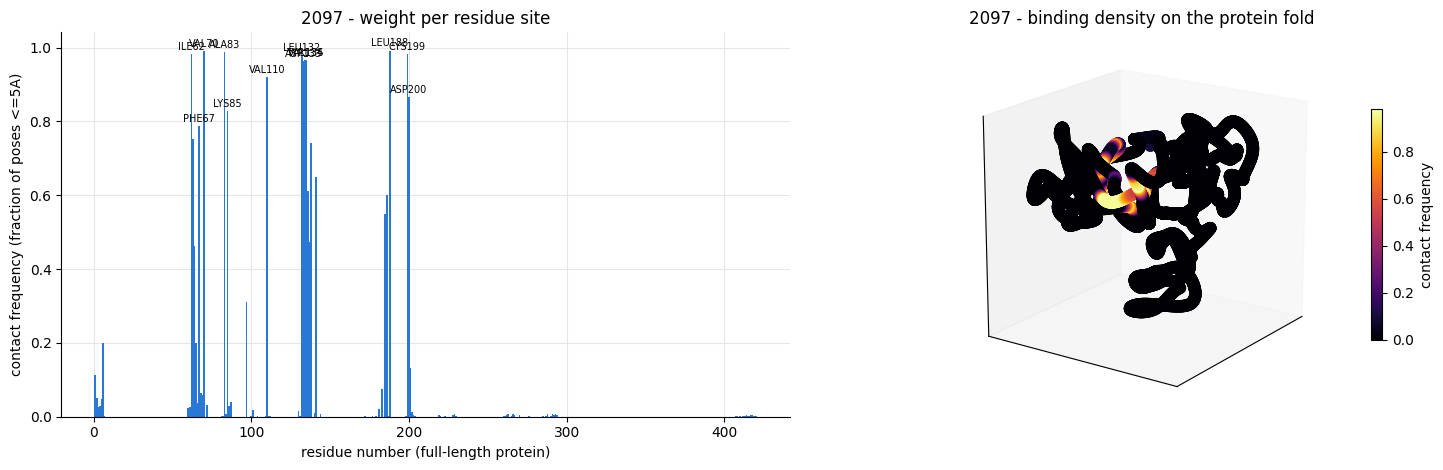

2097: top binding residues: LEU188(0.99), VAL70(0.99), ALA83(0.99), ILE62(0.98), CYS199(0.98), LEU132(0.98), TYR134(0.97), VAL135(0.97)


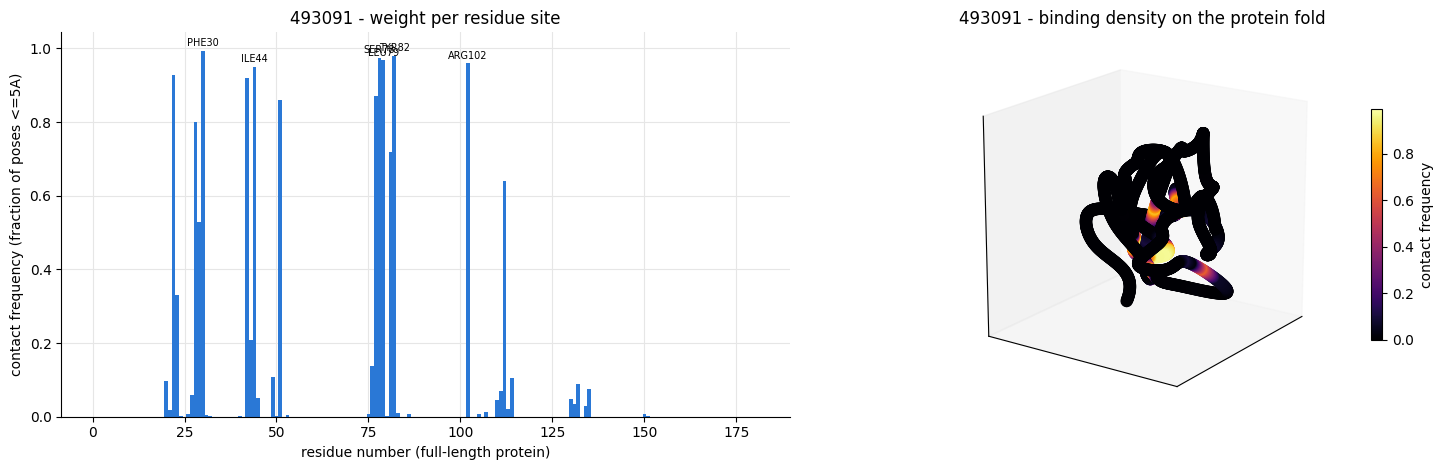

493091: top binding residues: PHE30(0.99), TYR82(0.98), SER78(0.98), LEU79(0.97), ARG102(0.96), ILE44(0.95), ASP22(0.93), VAL42(0.92)


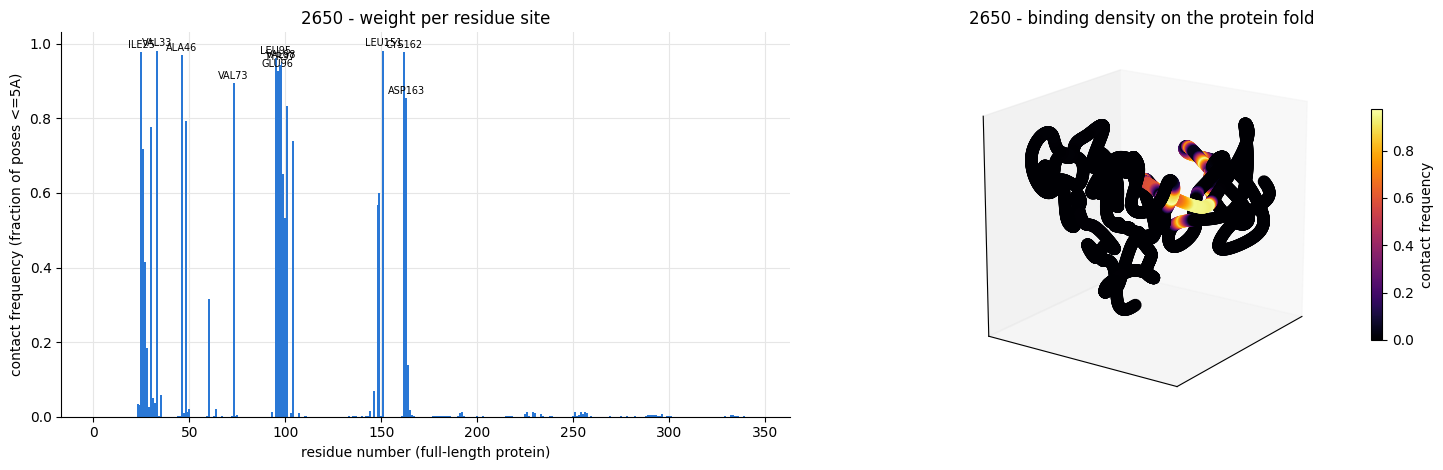

2650: top binding residues: VAL33(0.98), LEU151(0.98), CYS162(0.98), ILE25(0.98), ALA46(0.97), LEU95(0.96), VAL98(0.95), TYR97(0.94)


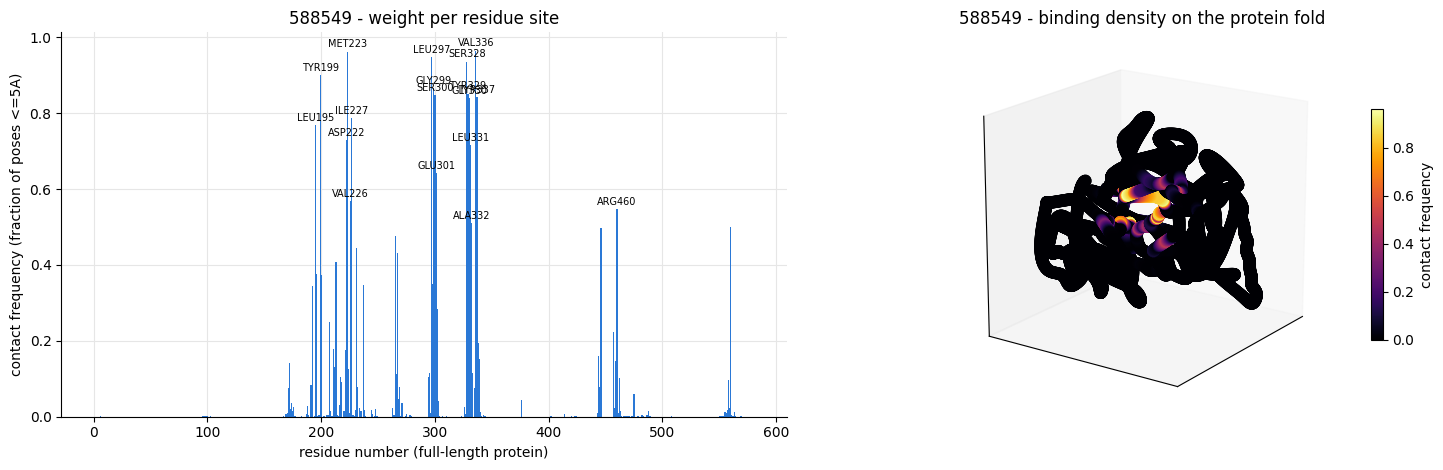

588549: top binding residues: VAL336(0.96), MET223(0.96), LEU297(0.95), SER328(0.94), TYR199(0.90), GLY299(0.87), TYR329(0.85), SER300(0.85)


In [2]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.interpolate import splprep, splev
def ribbon(ax,ca,dens):
    # smooth B-spline through the CA trace -> a tube coloured by per-residue density (a backbone cartoon)
    n=len(ca); k=min(3,n-1)
    try:
        tck,u=splprep([ca[:,0],ca[:,1],ca[:,2]],s=n*3.0,k=k); uu=np.linspace(0,1,n*14)
        sx,sy,sz=splev(uu,tck); pts=np.array([sx,sy,sz]).T
        di=np.interp(uu,np.linspace(0,1,n),dens)
    except Exception:
        pts=ca; di=dens
    segs=np.stack([pts[:-1],pts[1:]],axis=1)
    lc=Line3DCollection(segs,cmap="inferno",linewidths=9); lc.set_array(di[:-1]); lc.set_capstyle("round")
    ax.add_collection3d(lc)
    mn=pts.min(0); mx=pts.max(0); c=(mn+mx)/2; rad=(mx-mn).max()/2*1.05
    ax.set_xlim(c[0]-rad,c[0]+rad); ax.set_ylim(c[1]-rad,c[1]+rad); ax.set_zlim(c[2]-rad,c[2]+rad)
    try: ax.set_box_aspect((1,1,1))
    except Exception: pass
    return lc
for t in DONE:
    df,z=DATA[t]; ca=z["ca"]; dens=z["contact_frac"]
    fig=plt.figure(figsize=(15,4.8))
    # (1) per-residue profile along sequence
    ax1=fig.add_subplot(1,2,1)
    ax1.bar(df.res_num,df.contact_frac,width=1.0,color="#2a78d6")
    ax1.set_xlabel("residue number (full-length protein)"); ax1.set_ylabel("contact frequency (fraction of poses <=5A)")
    ax1.set_title(f"{SHORT[t]} - weight per residue site"); ax1.spines[["top","right"]].set_visible(False)
    thr=df.contact_frac.quantile(0.97)
    for _,r in df[df.contact_frac>=thr].iterrows():
        ax1.annotate(f"{r.res_name}{int(r.res_num)}",(r.res_num,r.contact_frac),textcoords="offset points",xytext=(0,3),ha="center",fontsize=7)
    # (2) the real protein backbone as a ribbon/tube, coloured by density
    ax2=fig.add_subplot(1,2,2,projection="3d")
    lc=ribbon(ax2,ca,dens)
    ax2.set_title(f"{SHORT[t]} - binding density on the protein fold"); ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
    ax2.grid(False); ax2.view_init(elev=18,azim=35)
    fig.colorbar(lc,ax=ax2,shrink=0.6,label="contact frequency")
    plt.tight_layout(); plt.show()
    top=df.sort_values("contact_frac",ascending=False).head(8)
    print(f"{SHORT[t]}: top binding residues:", ", ".join(f"{r.res_name}{int(r.res_num)}({r.contact_frac:.2f})" for _,r in top.iterrows()))

## How focused is the binding across targets?
The share of total contact weight held by each target's top-10 residues. High = one tight pocket dominates; low = the ligands spread over several sites or a shallow surface.

,residues,top10_share,residues_over_50pct,peak_residue
target,,,,
588689 (NS5 MTase),275,0.662,11,LEU17
504329,219,0.553,12,VAL180
743445,141,0.747,13,VAL21
485317,139,0.567,16,GLY37
2097,420,0.518,19,LEU188
493091,180,0.686,14,PHE30
2650,345,0.520,20,VAL33
588549,580,0.387,19,VAL336


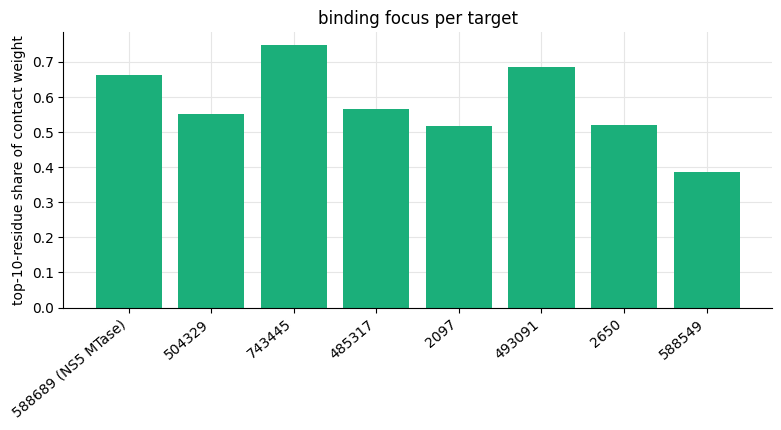

In [3]:
rows=[]
for t in DONE:
    df,_=DATA[t]; tot=df.contact_frac.sum()
    top10=df.contact_frac.nlargest(10).sum()
    n_hot=(df.contact_frac>=0.5).sum()
    pk=df.loc[df.contact_frac.idxmax()]; peak=f"{pk.res_name}{int(pk.res_num)}"
    rows.append(dict(target=SHORT[t], residues=len(df), top10_share=round(top10/tot,3) if tot>0 else 0,
                     residues_over_50pct=int(n_hot), peak_residue=peak))
if rows:
    s=pd.DataFrame(rows).set_index("target"); display(s)
    fig,ax=plt.subplots(figsize=(8,4.4)); ax.bar(range(len(s)),s.top10_share,color="#1baf7a")
    ax.set_xticks(range(len(s))); ax.set_xticklabels(s.index,rotation=40,ha="right"); ax.set_ylabel("top-10-residue share of contact weight")
    ax.set_title("binding focus per target"); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()
else: print("no targets done yet")

## Notes

- **On the real structure, not a reference frame.** Contact frequency is computed per residue within each complex's own coordinates, so it is anchored to the actual residues/fold; the 3D panel paints that density onto real CA positions. A density-coloured PDB (B-factor = contact frequency) is also saved per target under `results/runs/<T>/pose_density/` for opening in PyMOL/ChimeraX.
- **Self-filling.** Targets appear as their Pass-1 structures finish; 588689 is complete, others fill in. Numbers use a sample of poses per target (stable for frequencies).
- **Reading it.** A single dominant peak means the library funnels into one pocket; secondary peaks flag alternative/surface sites - relevant to whether a confidence or pose filter would help (cross-reference the uncertainty notebooks).